# 동학개미는 정말 이겼을까: 5년치 순매수 데이터의 답

## 2. 탐색적 분석 (EDA)

### 이 노트북의 역할
1. 개인 순매수 상위 종목의 연도별 특성 파악
2. 순매수 금액 분포와 집중도 분석
3. 개미가 선호하는 종목의 패턴 발견
4. 백테스트(3번 노트북) 전 데이터 이해

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows)
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()
fm.fontManager.addfont(font_path)
mpl.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style("whitegrid", {"font.family": font_name})

# 데이터 로드
top_stocks = pd.read_csv('../data/top_stocks.csv')
prices = pd.read_csv('../data/prices.csv')
kospi = pd.read_csv('../data/kospi.csv')

prices['날짜'] = pd.to_datetime(prices['날짜'])
kospi['날짜'] = pd.to_datetime(kospi['날짜'])

print(f"순매수 상위: {len(top_stocks)}행, {top_stocks['종목코드'].nunique()}종목")
print(f"주가 데이터: {len(prices):,}행")
print(f"코스피 지수: {len(kospi)}일")

prices['ticker'] = prices['ticker'].astype(str).str.zfill(6)

순매수 상위: 120행, 67종목
주가 데이터: 89,174행
코스피 지수: 1471일


## 1. 연도별 순매수 금액 분포

개인 투자자의 순매수 집중도를 파악합니다.
- 상위 종목에 얼마나 집중되어 있는가?
- 연도별로 집중도가 달라지는가?

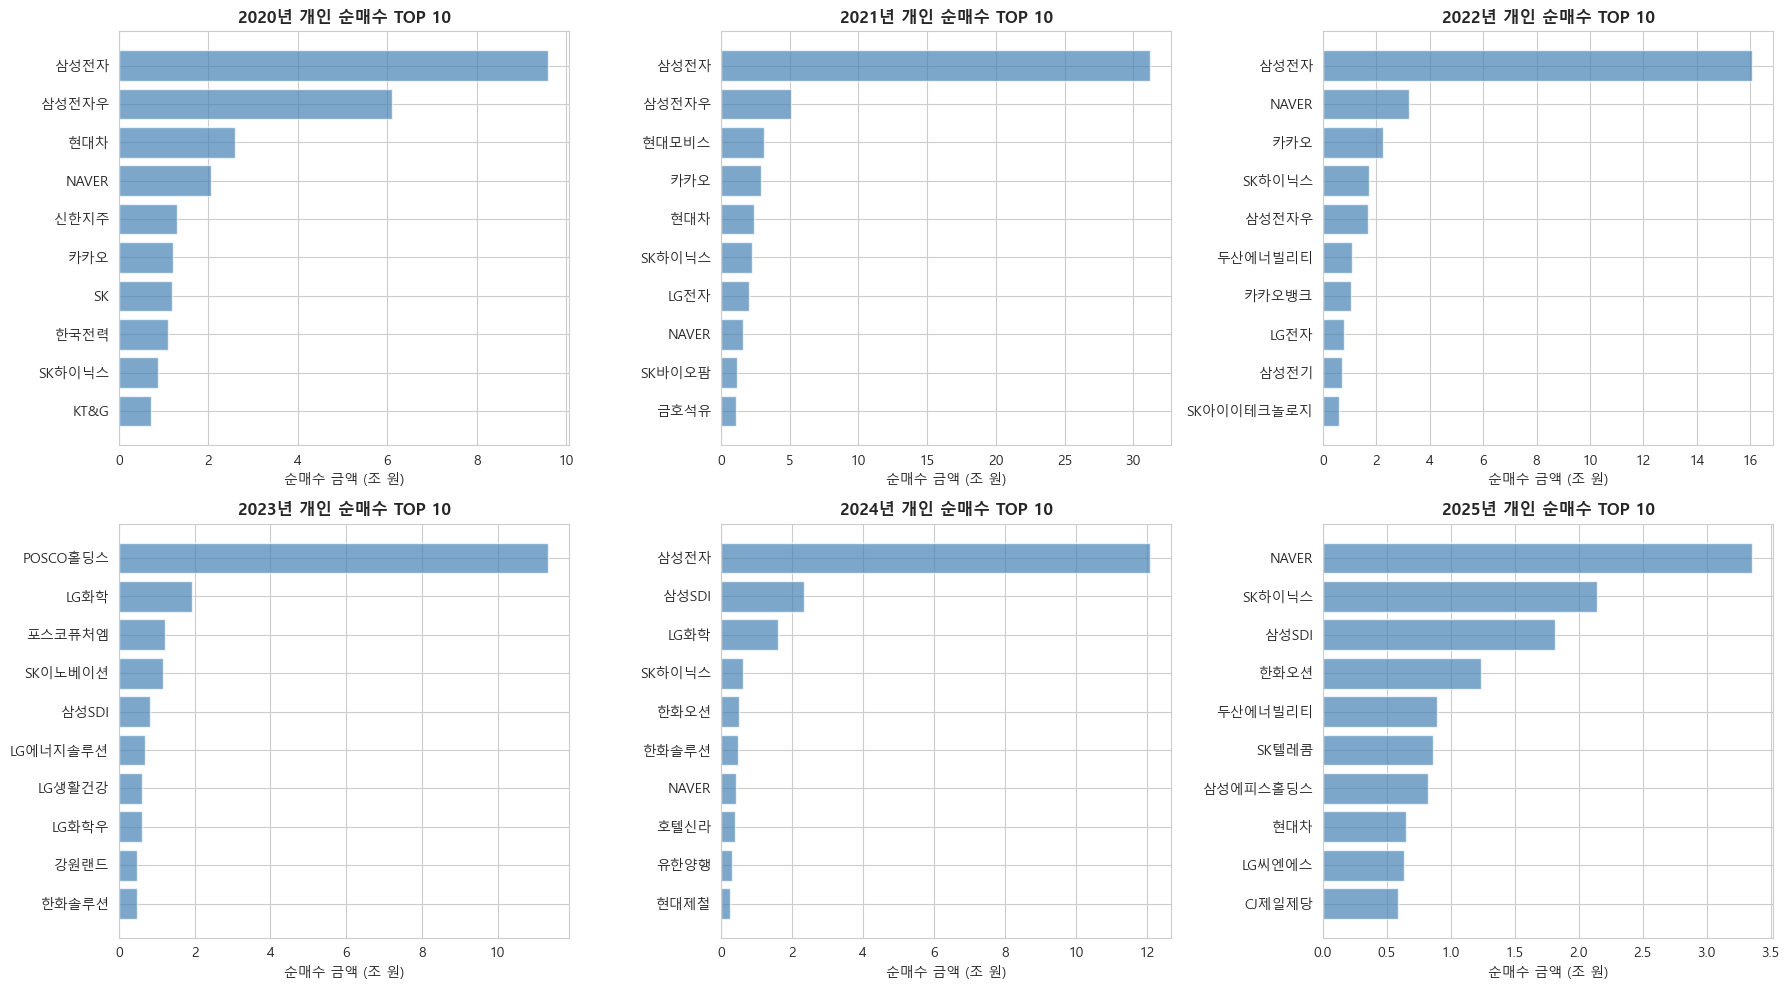

In [10]:
# 연도별 순매수 금액 상위 5종목
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, year in enumerate([2020, 2021, 2022, 2023, 2024, 2025]):
    yearly = top_stocks[top_stocks['year'] == year].head(10)
    
    ax = axes[i]
    bars = ax.barh(
        yearly['종목명'][::-1],
        yearly['거래대금_순매수'][::-1] / 1e12,  # 조 단위
        color='steelblue', alpha=0.7
    )
    ax.set_xlabel('순매수 금액 (조 원)')
    ax.set_title(f'{year}년 개인 순매수 TOP 10', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/yearly_top10.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# 연도별 순매수 집중도: 1위 종목이 전체 상위 20 중 차지하는 비중
print("=" * 50)
print("연도별 순매수 집중도 분석")
print("=" * 50)

for year in [2020, 2021, 2022, 2023, 2024, 2025]:
    yearly = top_stocks[top_stocks['year'] == year]
    total = yearly['거래대금_순매수'].sum()
    top1 = yearly.iloc[0]
    top1_pct = top1['거래대금_순매수'] / total * 100
    top5_pct = yearly.head(5)['거래대금_순매수'].sum() / total * 100
    
    print(f"\n{year}년:")
    print(f"  1위: {top1['종목명']} ({top1_pct:.1f}%)")
    print(f"  상위 5종목 집중도: {top5_pct:.1f}%")

연도별 순매수 집중도 분석

2020년:
  1위: 삼성전자 (30.4%)
  상위 5종목 집중도: 68.5%

2021년:
  1위: 삼성전자 (51.1%)
  상위 5종목 집중도: 73.3%

2022년:
  1위: 삼성전자 (48.0%)
  상위 5종목 집중도: 74.5%

2023년:
  1위: POSCO홀딩스 (50.9%)
  상위 5종목 집중도: 73.9%

2024년:
  1위: 삼성전자 (56.9%)
  상위 5종목 집중도: 80.8%

2025년:
  1위: NAVER (20.1%)
  상위 5종목 집중도: 56.7%


In [12]:
# 종목 등장 빈도: 개미가 꾸준히 사는 종목 vs 한 해만 사는 종목
ticker_freq = top_stocks.groupby('종목명')['year'].agg(['count', list]).sort_values('count', ascending=False)
ticker_freq.columns = ['등장횟수', '등장연도']

print("=" * 50)
print("개미가 꾸준히 사는 종목 (3년 이상)")
print("=" * 50)
repeat = ticker_freq[ticker_freq['등장횟수'] >= 3]
for name, row in repeat.iterrows():
    years = sorted(row['등장연도'])
    print(f"  {name}: {row['등장횟수']}년 ({', '.join(map(str, years))})")

print(f"\n1년만 등장: {len(ticker_freq[ticker_freq['등장횟수'] == 1])}종목")
print(f"2년 등장: {len(ticker_freq[ticker_freq['등장횟수'] == 2])}종목")
print(f"3년 이상: {len(repeat)}종목")

개미가 꾸준히 사는 종목 (3년 이상)
  SK하이닉스: 5년 (2020, 2021, 2022, 2024, 2025)
  NAVER: 5년 (2020, 2021, 2022, 2024, 2025)
  삼성전자: 4년 (2020, 2021, 2022, 2024)
  LG생활건강: 4년 (2021, 2022, 2023, 2025)
  현대차: 4년 (2020, 2021, 2022, 2025)
  삼성전자우: 3년 (2020, 2021, 2022)
  카카오: 3년 (2020, 2021, 2022)
  한화솔루션: 3년 (2023, 2024, 2025)
  삼성SDI: 3년 (2023, 2024, 2025)
  SK이노베이션: 3년 (2020, 2021, 2023)

1년만 등장: 37종목
2년 등장: 23종목
3년 이상: 10종목


## 2. 개미 순매수 종목의 주가 성과 미리보기

개미가 많이 산 종목의 주가가 실제로 어떻게 움직였는지 시각적으로 파악합니다.
코스피 지수 대비 상대 성과를 확인합니다.

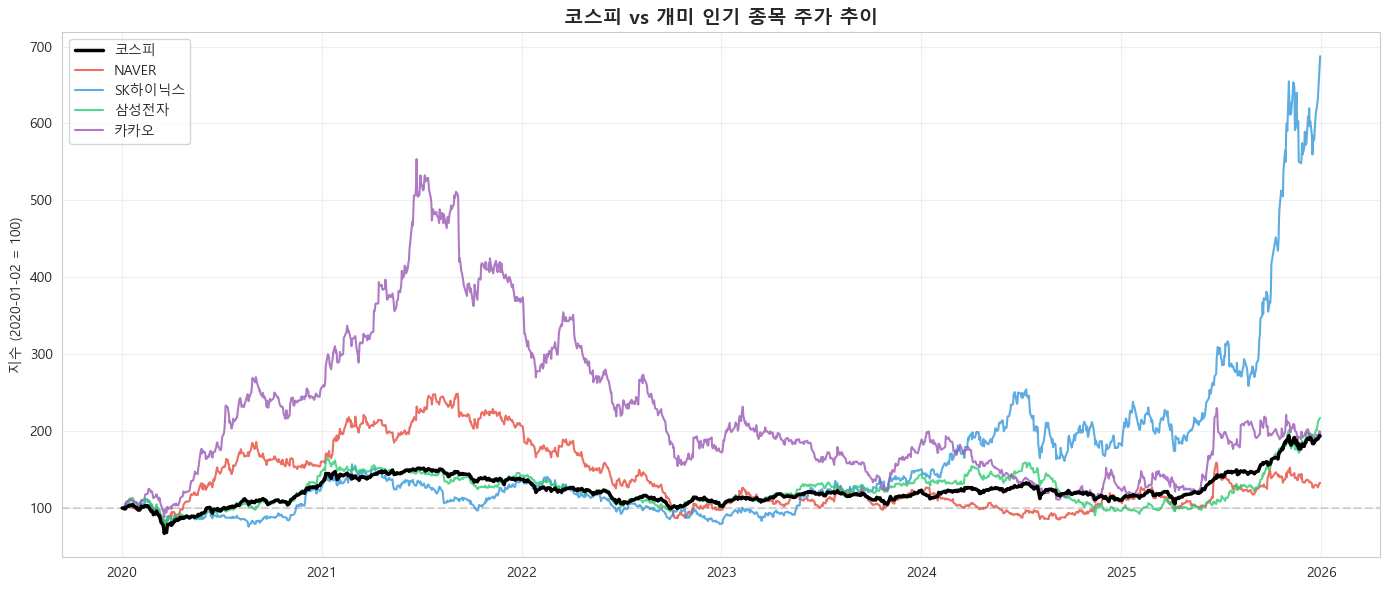

In [13]:
# 코스피 vs 개미 인기 종목 주가 추이 (2020년 1월 = 100 기준 인덱스화)
fig, ax = plt.subplots(figsize=(14, 6))

# 코스피 인덱스화
kospi_indexed = kospi.copy()
kospi_indexed['index'] = kospi_indexed['종가'] / kospi_indexed['종가'].iloc[0] * 100
ax.plot(kospi_indexed['날짜'], kospi_indexed['index'], 
        color='black', linewidth=2.5, label='코스피', zorder=5)

# 5년 연속 상위 종목 (NAVER, SK하이닉스)
highlight = ['NAVER', 'SK하이닉스', '삼성전자', '카카오']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

for name, color in zip(highlight, colors):
    ticker = top_stocks[top_stocks['종목명'] == name]['종목코드'].iloc[0]
    stock_data = prices[prices['ticker'] == ticker].sort_values('날짜')
    stock_data = stock_data.copy()
    stock_data['index'] = stock_data['종가'] / stock_data['종가'].iloc[0] * 100
    ax.plot(stock_data['날짜'], stock_data['index'], 
            linewidth=1.5, label=name, color=color, alpha=0.8)

ax.axhline(y=100, color='gray', linestyle='--', alpha=0.3)
ax.set_ylabel('지수 (2020-01-02 = 100)')
ax.set_title('코스피 vs 개미 인기 종목 주가 추이', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../images/price_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# 연도별 수익률 비교: 코스피 vs 개미 상위 종목 개별
print("=" * 60)
print("연도별 수익률 비교 (연초 → 연말)")
print("=" * 60)

for year in [2020, 2021, 2022, 2023, 2024, 2025]:
    # 코스피 연간 수익률
    kospi_year = kospi[(kospi['날짜'].dt.year == year)]
    if len(kospi_year) < 2:
        continue
    kospi_ret = (kospi_year['종가'].iloc[-1] / kospi_year['종가'].iloc[0] - 1) * 100
    
    # 해당 연도 상위 5종목의 연간 수익률
    yearly_top = top_stocks[top_stocks['year'] == year].head(5)
    
    print(f"\n{year}년 (코스피: {kospi_ret:+.1f}%)")
    print(f"  {'종목':<15} {'수익률':>10}")
    print(f"  {'-'*27}")
    
    for _, row in yearly_top.iterrows():
        stock_data = prices[
            (prices['ticker'] == row['종목코드']) & 
            (prices['날짜'].dt.year == year)
        ].sort_values('날짜')
        
        if len(stock_data) < 2:
            continue
            
        ret = (stock_data['종가'].iloc[-1] / stock_data['종가'].iloc[0] - 1) * 100
        beat = "✅" if ret > kospi_ret else "❌"
        print(f"  {row['종목명']:<15} {ret:>+8.1f}%  {beat}")

연도별 수익률 비교 (연초 → 연말)

2020년 (코스피: +32.1%)
  종목                     수익률
  ---------------------------
  삼성전자               +46.7%  ✅
  삼성전자우              +61.4%  ✅
  현대차                +62.7%  ✅
  NAVER              +60.3%  ✅
  신한지주               -24.8%  ❌

2021년 (코스피: +1.1%)
  종목                     수익률
  ---------------------------
  삼성전자                -5.7%  ❌
  삼성전자우               -4.3%  ❌
  현대모비스              -11.3%  ❌
  카카오                +41.5%  ✅
  현대차                 +0.7%  ❌

2022년 (코스피: -25.2%)
  종목                     수익률
  ---------------------------
  삼성전자               -29.6%  ❌
  NAVER              -52.8%  ❌
  카카오                -53.6%  ❌
  SK하이닉스             -41.6%  ❌
  삼성전자우              -29.3%  ❌

2023년 (코스피: +19.3%)
  종목                     수익률
  ---------------------------
  POSCO홀딩스           +83.6%  ✅
  LG화학               -17.4%  ❌
  포스코퓨처엠             +87.5%  ✅
  SK이노베이션             -8.0%  ❌
  삼성SDI              -21.6%  ❌

2024년 (코스피: -10.1%)
  종목               

## 3. EDA 결론

### 핵심 발견

1. **순매수 집중도가 매우 높음**: 상위 5종목이 전체의 57~81% 차지. 특히 삼성전자 1종목이 30~57%
2. **개미 인기 종목은 대형주 편향**: 삼성전자, SK하이닉스, NAVER 등 시가총액 상위 종목에 집중
3. **2020년만 코스피 초과, 2021~2022년은 완패**: 코로나 반등기에만 성과, 이후 하락장에서 코스피보다 더 큰 손실
4. **개미가 꾸준히 사는 종목(5년 연속)과 한 해만 사는 종목(37개)의 대비**: 테마주 추격 매수 패턴 존재